In [17]:
import pandas as pd

df_english = pd.read_csv('./cleaned_songs_with_lyrics.csv')

In [18]:
df_english[['track_genre','id']].groupby(by=["track_genre"]).count()

,id
track_genre,
afrobeat,96
alt-rock,65
alternative,75
ambient,124
anime,73
...,...
spanish,13
synth-pop,517
techno,82


In [19]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from textblob import TextBlob # TextBlob doesn't require a separate download for basic sentiment



# 2. Extract Sentiment (Polarity: -1 to 1, Subjectivity: 0 to 1)
def get_sentiment(text):
    blob = TextBlob(str(text))
    return blob.sentiment.polarity, blob.sentiment.subjectivity

df_english[['polarity', 'subjectivity']] = df_english['lyrics_cleaned'].apply(
    lambda x: pd.Series(get_sentiment(x))
)

In [20]:
df_sentiment = df_english[['track_genre','polarity', 'subjectivity']].groupby('track_genre').mean()

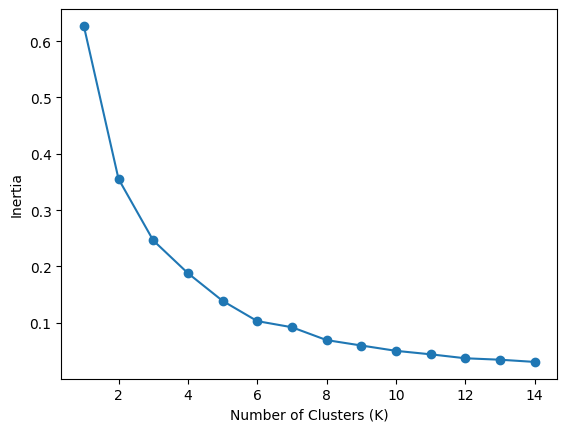

In [21]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
def plot_elbow(df: pd.DataFrame):
    '''
    Plots the elbow for clusters between 1 and 9

    Args:
        df (pd.DataFrame): dataframe being clustered
    '''
    inertia = []

    k_range = range(1,15)

    df_sentiment = df[['track_genre','polarity', 'subjectivity']].groupby('track_genre').mean()

    for k in k_range:
        model = KMeans(n_clusters=k,random_state = 42)
        model.fit(df_sentiment)
        inertia.append(model.inertia_)

    plt.plot(k_range, inertia, marker='o')
    plt.xlabel('Number of Clusters (K)')
    plt.ylabel('Inertia')
    plt.show()

    return df_sentiment

df_sentiment = plot_elbow(df_english)

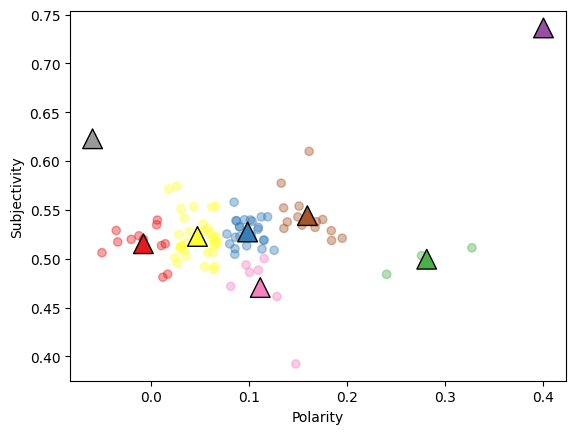

In [22]:
def calc_and_plot_clusters(df: pd.DataFrame, k: int):
    '''
    Calculates the kmeans and plots the clusters (faded circles), and the calculated cluster centeres (Triangles)

    Args:
        df (pd.DataFrame): dataframe being clustered
        k (int): number of clusters
    '''
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df)
    df['cluster'] = kmeans.labels_
    plt.scatter(df.iloc[:,0],df.iloc[:,1], c=df['cluster'], alpha=0.4,cmap='Set1')
    plt.scatter(
        kmeans.cluster_centers_[:k,0],
        kmeans.cluster_centers_[:k,1],
        c=np.unique(kmeans.labels_),
        s=200,
        marker='^',
        edgecolors='black',
        cmap='Set1'
        )
    plt.xlabel('Polarity')
    plt.ylabel('Subjectivity')

    return df

df_cleaned = calc_and_plot_clusters(df_sentiment,8)

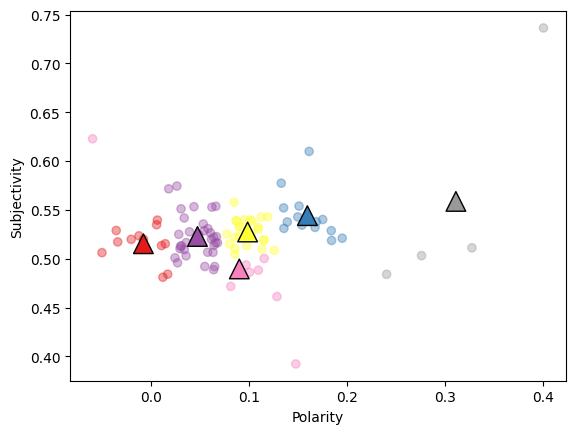

In [23]:
df_cleaned = calc_and_plot_clusters(df_sentiment,6)

In [24]:
# Count genres
counts = df_english['track_genre'].value_counts()

# Filter for genres with 10+ members
df_english = df_english[df_english['track_genre'].isin(counts[counts >= 10].index)].copy()
# 3. Define the ColumnTransformer
# This allows us to process text and numeric features simultaneously
preprocessor = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(max_features=5000, stop_words='english'), 'lyrics_cleaned'),
        ('num', StandardScaler(), ['polarity', 'subjectivity'])
    ]
)

# 4. Final Pipeline
model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000))
])
# 5. Split and Train
X = df_english[['lyrics_cleaned', 'polarity', 'subjectivity']]
y = df_english['track_genre']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

model_pipeline.fit(X_train, y_train)

# Generate class predictions (e.g., 'rock', 'pop')
y_pred = model_pipeline.predict(X_test)

# Generate probability scores (if you want to see how confident the model is)
y_probs = model_pipeline.predict_proba(X_test)

df_preds = pd.DataFrame({
    'lyrics': X_test.index,
    'actual_parent': y_test,
    'predicted_genre': y_pred
})


In [25]:
df_preds['Equal?'] = df_preds['actual_parent'] == df_preds['predicted_genre']

In [26]:
to_remove = ['guitar', 'happy', 'malay', 'sleep']

df_final_genre_list = df_english[~df_english['track_genre'].isin(to_remove)]

In [27]:
import re
subgenre = pd.read_csv('./genres.csv',index_col='subgenre')['parent'].str.lower()

df_final_genre_list['track_genre'] = [re.sub('[-]',"",x) for x in df_final_genre_list['track_genre'].to_list()]
df_final_genre_list['parent_genre'] = df_final_genre_list['track_genre'].map(subgenre)



C:\Users\conno\AppData\Local\Temp\ipykernel_16616\3904020364.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final_genre_list['track_genre'] = [re.sub('[-]',"",x) for x in df_final_genre_list['track_genre'].to_list()]
C:\Users\conno\AppData\Local\Temp\ipykernel_16616\3904020364.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final_genre_list['parent_genre'] = df_final_genre_list['track_genre'].map(subgenre)


In [16]:

preprocessor = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(max_features=5000, stop_words='english'), 'lyrics_cleaned'),
        ('num', StandardScaler(), ['polarity', 'subjectivity'])
    ]
)

# 4. Final Pipeline
model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000))
])
# 5. Split and Train
X = df_final_genre_list[['lyrics_cleaned', 'polarity', 'subjectivity']]
y = df_final_genre_list['parent_genre']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

model_pipeline.fit(X_train, y_train)

# Generate class predictions (e.g., 'rock', 'pop')
y_pred = model_pipeline.predict(X_test)

# Generate probability scores (if you want to see how confident the model is)
y_probs = model_pipeline.predict_proba(X_test)

df_preds = pd.DataFrame({
    'lyrics': X_test.index,
    'actual_parent': y_test,
    'predicted_genre': y_pred
})


In [ ]:
# Im thinking

# We use the 97 predefined genres. 

# We do sentiment analysis to try and extract the emotions from the song

# We esentially make a matrix and cluster the genres together inter a more manageable amount of groups

# We since these clusters would have more similarity, we now ignore sentiment, and only use word based methods to try to do supervised 
# learning and define the specific genre

# Then we can analyse to see if specific emotional charge have enough variation between genres.csv

# We can also see if the spotigfy defined genres are better than out clustered ones, and see if we can use our own judgement to identify why sentiment has 
# showed these variations and if we can identify the parent genre.